# COMP4030: Long-Form Text Summarisation
**Author:** Zeba Vora | **Module:** COMP4030 | **University of Nottingham**

The big question behind this project: how do you summarise a document that's too long for an AI to read in one go? I tested three different strategies and compared how well they work depending on what the user actually wants from the summary.

**Research Questions**
- RQ1: Which approach produces the best summaries — baseline, chunked, or RAG?
- RQ2: Does what the user asks for (concise / detailed / query-based) affect which method wins?
- RQ3: Do ROUGE-1, ROUGE-2 and ROUGE-L agree with each other?

## Reproducibility & Running Instructions

This notebook runs fully offline using precomputed results.

All required data and outputs are provided in the accompanying ZIP file:
`DataFiles_20793247.zip`

### Setup

1. Extract `DataFiles_20793247.zip`  
2. Place the extracted folder (`DataFiles_20793247/`) in the **same directory** as this notebook  

### Running the Notebook

- Keep `regenerate = False` (default)  
- Click **Run All**

All tables, scores, and figures will be reproduced exactly as reported.

### Optional: Regenerating Results

To regenerate results using the API:

- Set `regenerate = True`  
- Provide a valid OpenAI API key  

This step is optional and not required for evaluation.

In [38]:
print("Running in cached mode, no API required.")

Running in cached mode, no API required.


## 1. Imports and Setup

In [39]:
import os, re, json, time, random
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from scipy.stats import wilcoxon

random.seed(42)
np.random.seed(42)

#crisp figures
matplotlib.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300,
                             "axes.spines.top": False, "axes.spines.right": False})

#folders
root     = Path.cwd()
data_dir = root / "data"
ref_dir  = data_dir / "references"
out_dir  = root / "outputs"
out_dir.mkdir(exist_ok=True)

if not data_dir.exists():
    raise FileNotFoundError("data/ folder not found. Please include it with the notebook.")

#story paths
story_files = {
    "speckled_band"   : data_dir / "speckled_band.txt",
    "yellow_wallpaper": data_dir / "yellow_wallpaper.txt",
    "tale_heart"      : data_dir / "tale_heart.txt",
}

#two reference summaries per story (LitCharts + Wikipedia)
ref_files = {
    "speckled_band"   : [ref_dir / "speckled_band_summary.txt",    ref_dir / "speckled_band_wikipedia.txt"],
    "yellow_wallpaper": [ref_dir / "yellow_wallpaper_summary.txt", ref_dir / "yellow_wallpaper_wikipedia.txt"],
    "tale_heart"      : [ref_dir / "tale_heart_summary.txt",       ref_dir / "tale_heart_wikipedia.txt"],
}

#display names
names = {
    "speckled_band"   : "The Adventure of the Speckled Band",
    "yellow_wallpaper": "The Yellow Wallpaper",
    "tale_heart"      : "The Tell-Tale Heart",
}

#colours per story — used throughout
colours = {
    "speckled_band"   : "#5b8db8",
    "yellow_wallpaper": "#6abf8a",
    "tale_heart"      : "#e07b54",
}

#method colours
mcols = {"baseline": "#5b8db8", "chunked": "#6abf8a", "rag": "#e07b54"}

#settings
model      = "gpt-4o-mini"
temp       = 0
chunk_sz   = 300
top_k      = 5
regenerate = False

stop_words = set(stopwords.words("english"))

print("ready")
print(f"regenerate = {regenerate}")

ready
regenerate = False


## 2. Loading the Data

Three literary short stories from Project Gutenberg, each with two human-written reference summaries (LitCharts and Wikipedia). Using two references makes the ROUGE scores more reliable and less dependent on one person's writing style.

In [40]:
def load_text(path):
    for enc in ["utf-8", "utf-8-sig", "latin-1"]:
        try:
            return Path(path).read_text(encoding=enc).strip()
        except UnicodeDecodeError:
            continue

def clean_text(text):
    # remove gutenberg header/footer
    s = re.search(r"\*\*\* START OF.*?\*\*\*", text, re.DOTALL)
    e = re.search(r"\*\*\* END OF.*?\*\*\*",   text, re.DOTALL)
    if s and e:
        text = text[s.end():e.start()]

    # fix encoding artefacts
    fixes = {
        "\ufeff": "",
        "\t"    : " ",
        "\r"    : "\n",
        "\u2013": "-",
        "\u2014": "-",
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
    }
    for bad, good in fixes.items():
        text = text.replace(bad, good)

    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()


stories = {n: clean_text(load_text(p)) for n, p in story_files.items()}
refs    = {n: [clean_text(load_text(p)) for p in ps] for n, ps in ref_files.items()}

for n, t in stories.items():
    r1, r2 = refs[n]
    print(f"{names[n]}")
    print(f"  story: {len(t.split()):,} words | ref1: {len(r1.split())} words | ref2: {len(r2.split())} words")

The Adventure of the Speckled Band
  story: 9,812 words | ref1: 197 words | ref2: 575 words
The Yellow Wallpaper
  story: 6,085 words | ref1: 210 words | ref2: 331 words
The Tell-Tale Heart
  story: 2,079 words | ref1: 213 words | ref2: 465 words


## 3. Exploratory Data Analysis

Before doing anything, I wanted to understand what the data actually looks like? How long the stories are, what vocabulary they use, how sentences are structured.

In [41]:
def tokenise(text):
    return re.findall(r"[a-z]+", text.lower())

#dataset overview table
rows = []
for n, t in stories.items():
    sents = sent_tokenize(t)
    words = t.split()
    r1, r2 = refs[n]
    rows.append({
        "Story"         : names[n],
        "Words"         : f"{len(words):,}",
        "Sentences"     : len(sents),
        "Avg sent length": round(len(words)/len(sents), 1),
        "Vocab size"    : len(set(tokenise(t))),
        "Ref1 words"    : len(r1.split()),
        "Ref2 words"    : len(r2.split()),
    })

print(pd.DataFrame(rows).to_string(index=False))

                             Story Words  Sentences  Avg sent length  Vocab size  Ref1 words  Ref2 words
The Adventure of the Speckled Band 9,812        419             23.4        2039         197         575
              The Yellow Wallpaper 6,085        396             15.4        1223         210         331
               The Tell-Tale Heart 2,079        154             13.5         642         213         465


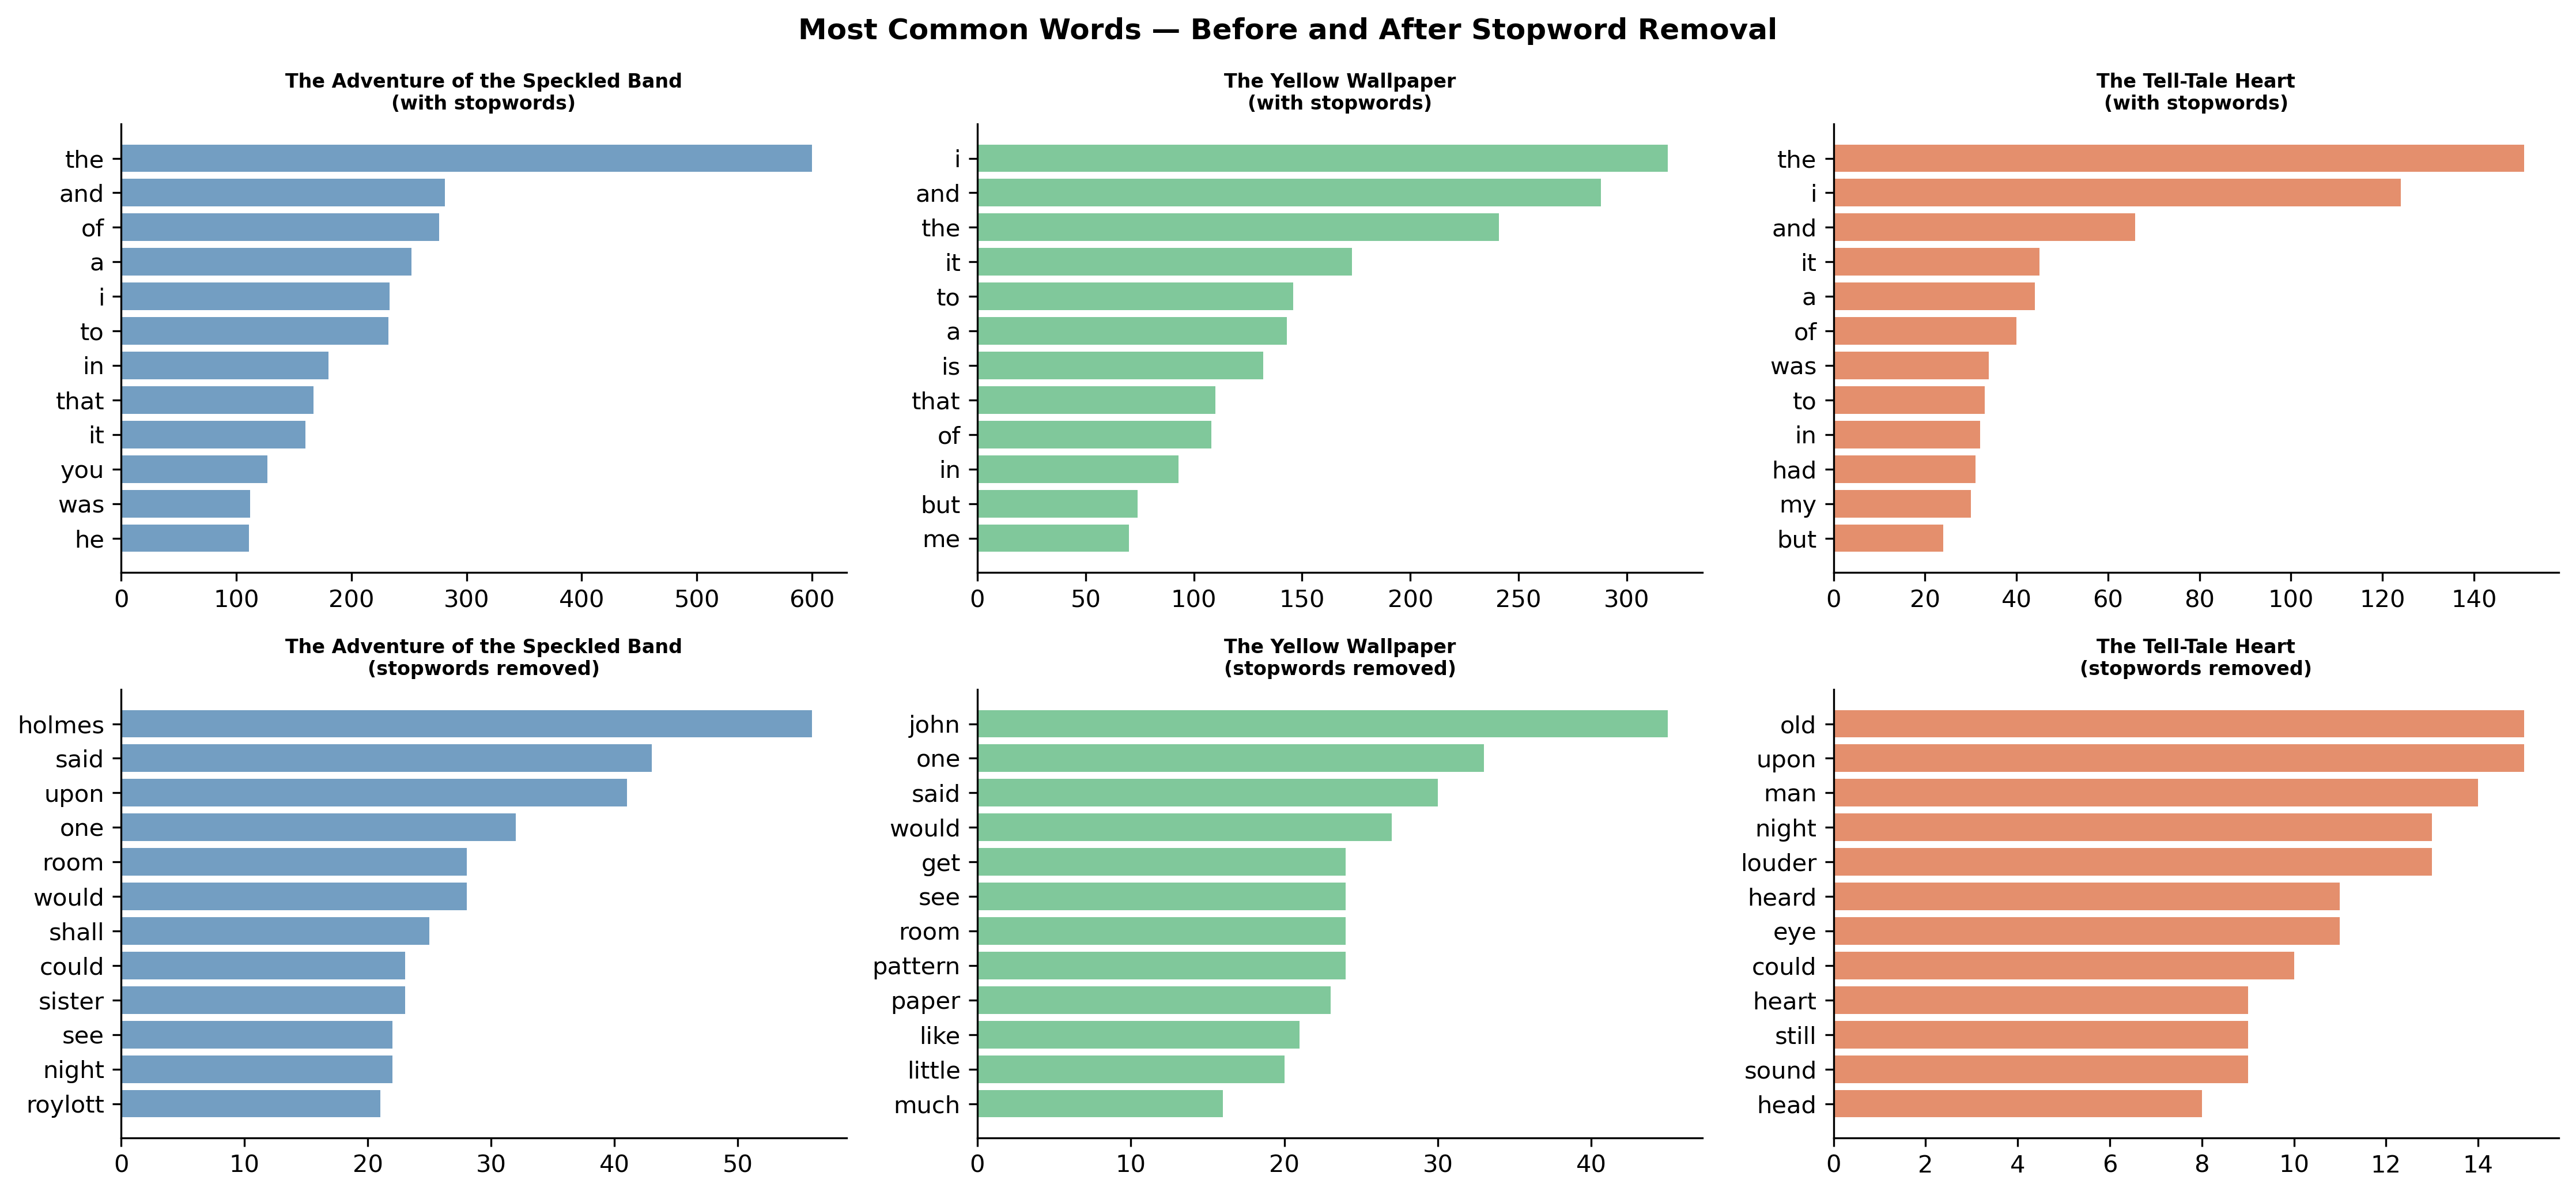

In [42]:
#most common words before and after stopword removal
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle("Most Common Words — Before and After Stopword Removal", fontsize=12, fontweight="bold")

for col, (n, t) in enumerate(stories.items()):
    tokens   = tokenise(t)
    filtered = [w for w in tokens if w not in stop_words and len(w) > 2]

    for row, words in enumerate([tokens, filtered]):
        top = Counter(words).most_common(12)
        ws, cs = zip(*top)
        axes[row][col].barh(ws[::-1], cs[::-1], color=colours[n], alpha=0.85)
        label = "with stopwords" if row == 0 else "stopwords removed"
        axes[row][col].set_title(f"{names[n]}\n({label})", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(out_dir / "eda_words.png", bbox_inches="tight")
plt.show()

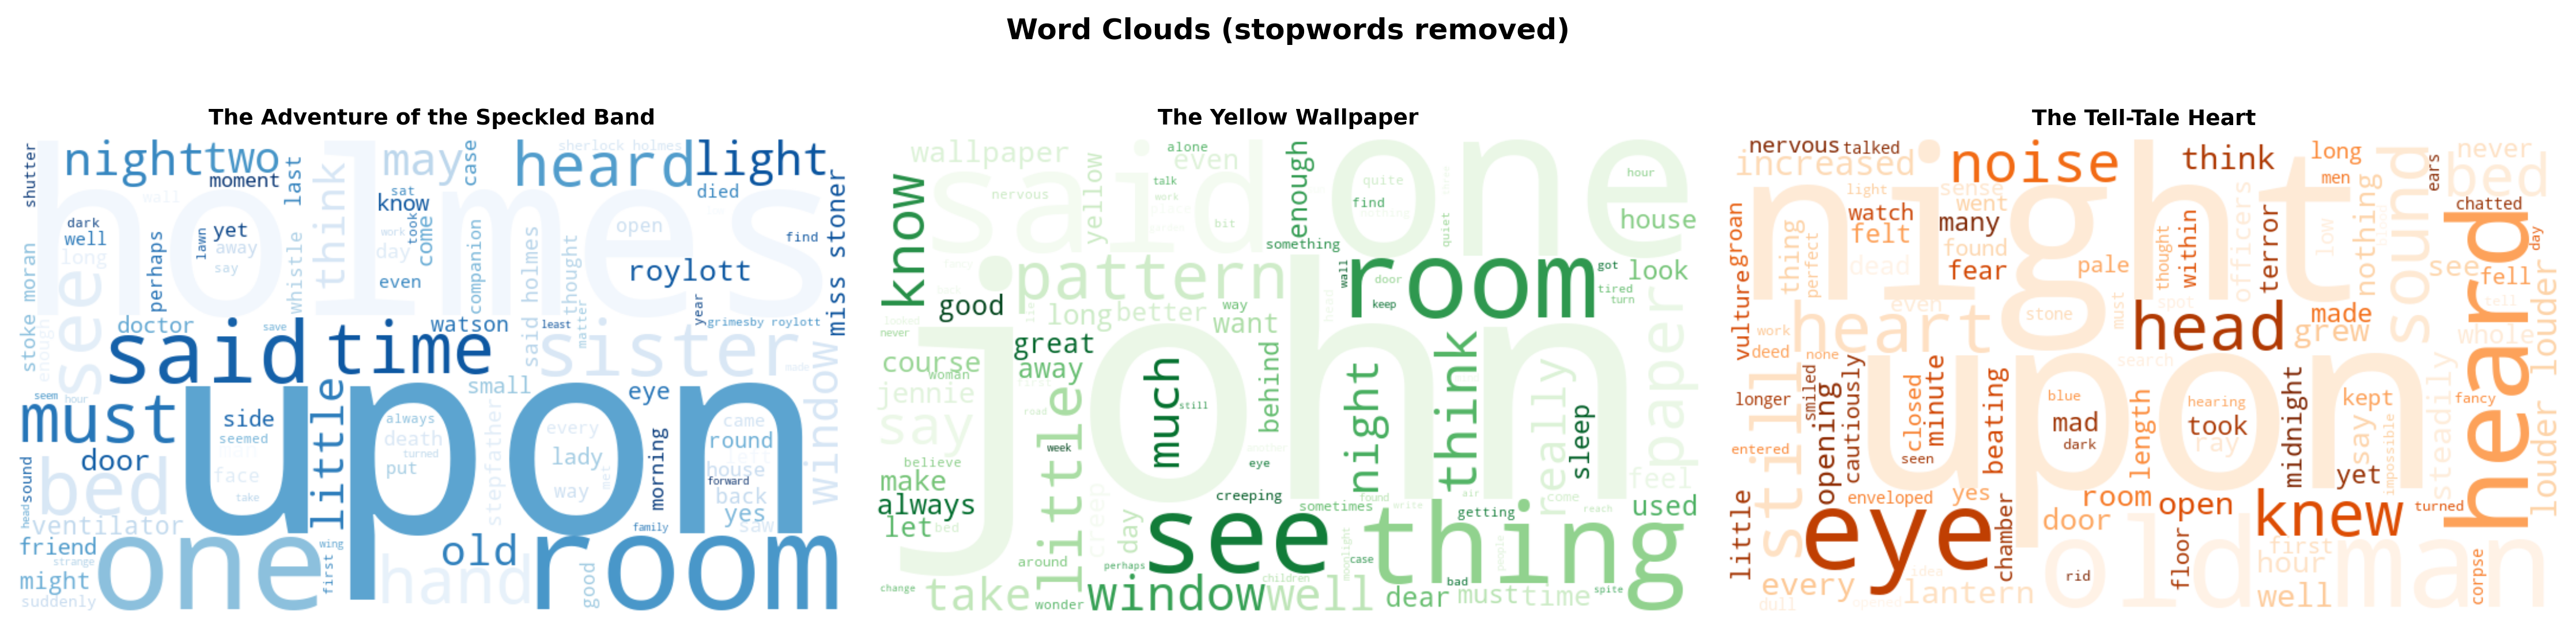

In [43]:
#word clouds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Word Clouds (stopwords removed)", fontsize=12, fontweight="bold")

cmaps = {"speckled_band": "Blues", "yellow_wallpaper": "Greens", "tale_heart": "Oranges"}

for ax, (n, t) in zip(axes, stories.items()):
    words = [w for w in tokenise(t) if w not in stop_words and len(w) > 2]
    wc = WordCloud(width=700, height=400, background_color="white",colormap=cmaps[n], max_words=100, random_state=42).generate(" ".join(words))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(names[n], fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / "eda_wordclouds.png", bbox_inches="tight")
plt.show()

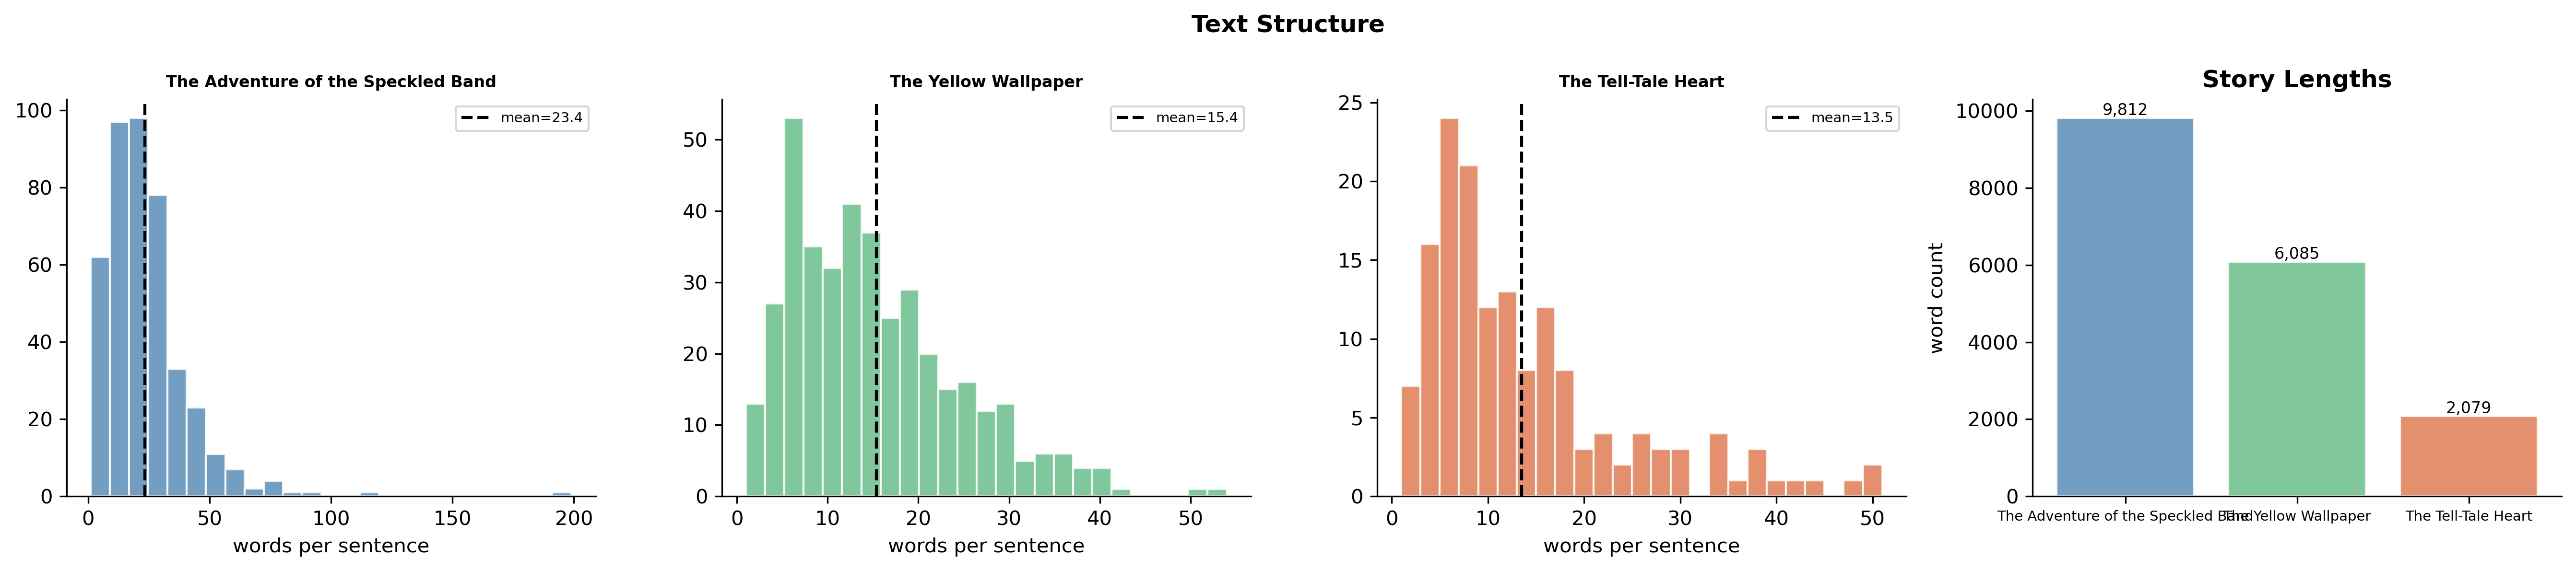

In [44]:
#sentence length distributions + story length comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Text Structure", fontsize=12, fontweight="bold")

for ax, (n, t) in zip(axes[:3], stories.items()):
    lens = [len(s.split()) for s in sent_tokenize(t)]
    ax.hist(lens, bins=25, color=colours[n], alpha=0.85, edgecolor="white")
    ax.axvline(np.mean(lens), color="black", linestyle="--", linewidth=1.5,label=f"mean={np.mean(lens):.1f}")
    ax.set_title(names[n], fontsize=8, fontweight="bold")
    ax.set_xlabel("words per sentence")
    ax.legend(fontsize=7)

#story length bar chart
wcs = [len(stories[n].split()) for n in stories]
bars = axes[3].bar([names[n] for n in stories], wcs,color=[colours[n] for n in stories], alpha=0.85, edgecolor="white")
axes[3].set_title("Story Lengths", fontweight="bold")
axes[3].set_ylabel("word count")
axes[3].tick_params(axis="x", labelsize=7)
for bar, val in zip(bars, wcs):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,f"{val:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / "eda_structure.png", bbox_inches="tight")
plt.show()

## 4. Preprocessing

The raw Gutenberg files had headers, footers, and weird encoding characters that needed cleaning before anything else. Here's what the cleaning actually does:

In [45]:
#show before/after cleaning on a messy example
raw = "It was\t\ta dark night.\r\n\r\n\r\nHolmes turned\u2014slowly\u2014and said \u201cElementary.\u201d"

print("BEFORE:")
print(repr(raw))
print()
print("AFTER:")
print(repr(clean_text(raw)))
print()
print("RENDERED:")
print(clean_text(raw))

BEFORE:
'It was\t\ta dark night.\r\n\r\n\r\nHolmes turned—slowly—and said “Elementary.”'

AFTER:
'It was a dark night.\n\nHolmes turned-slowly-and said "Elementary."'

RENDERED:
It was a dark night.

Holmes turned-slowly-and said "Elementary."


## 5. Chunking

Neither chunked nor RAG can pass the whole story to the model at once, so I split everything into 300-word chunks first. 300 words gives enough context per chunk without hitting model limits and it's the approach Wu et al. (2021) used in their recursive summarisation work.

In [46]:
def chunk_text(text, size=chunk_sz):
    words = text.split()
    return [" ".join(words[i:i+size]) for i in range(0, len(words), size)]

chunks = {n: chunk_text(t) for n, t in stories.items()}

for n, c in chunks.items():
    print(f"{names[n]}: {len(c)} chunks")

The Adventure of the Speckled Band: 33 chunks
The Yellow Wallpaper: 21 chunks
The Tell-Tale Heart: 7 chunks


## 6. API Setup

Only needed if `regenerate = True`. All the summaries are already saved, so you can skip this cell entirely when running in cached mode.

In [47]:
#paste your key here only if regenerating
os.environ["OPENAI_API_KEY"] = "YOUR_KEY_HERE"

In [48]:
from openai import OpenAI

def get_client():
    key = os.environ.get("OPENAI_API_KEY", "")
    if not key or key == "YOUR_KEY_HERE":
        raise ValueError("No API key. Set regenerate = False to use cached results.")
    return OpenAI(api_key=key)

def call_gpt(prompt):
    response = get_client().chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You summarise literary texts accurately and clearly."},
            {"role": "user",   "content": prompt}
        ],
        temperature=temp
    )
    return response.choices[0].message.content.strip()

def save_results(data, filename):
    with open(out_dir / filename, "w") as f:
        json.dump(data, f, indent=2)
    print(f"saved: {filename}")

def load_results(filename):
    with open(out_dir / filename) as f:
        return json.load(f)

print("api helper ready")

api helper ready


## 7. Prompts

Each story gets three different prompts depending on what the user wants. The prompts are tailored to the story title so the model knows exactly what it's working with.

In [49]:
def get_prompts(story_name):
    title = names[story_name]
    return {
        "concise": (
            f"Summarise '{title}' in 3-4 sentences. "
            f"Just the main events and outcome, nothing else."
        ),
        "detailed": (
            f"Write a detailed summary of '{title}' in 150-200 words. "
            f"Cover main events in order, key characters, the conflict, and the ending."
        ),
        "query_based": (
            f"Answer this about '{title}': What is the central conflict and how is it resolved? "
            f"Be specific — mention characters, events, and the ending. 80-120 words."
        ),
    }

print("prompts ready")

prompts ready


## 8. Baseline — TF-IDF Extractive

My baseline uses TF-IDF to score every sentence in a story by how important it is, picks the top 15, and sends those to GPT to rewrite into a proper summary. It reads the whole document which is fairer than just taking the first N words.

In [50]:
def run_baseline(story_name, text):
    prompts = get_prompts(story_name)
    results = {}

    #score sentences by tfidf importance
    sents    = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.split()) > 5]
    vec      = TfidfVectorizer(stop_words="english")
    matrix   = vec.fit_transform(sents)
    scores   = matrix.sum(axis=1).A1
    top      = sorted(scores.argsort()[::-1][:15])
    selected = " ".join([sents[i] for i in top])

    for intent, prompt in prompts.items():
        full_prompt = f"{prompt}\n\nExtracted passages:\n{selected}"
        start = time.time()
        results[intent] = {
            "summary": call_gpt(full_prompt),
            "runtime": round(time.time() - start, 2)
        }

    return results


if regenerate:
    print("running baseline...")
    baseline = {n: run_baseline(n, t) for n, t in stories.items()}
    save_results(baseline, "baseline_results.json")
else:
    baseline = load_results("baseline_results.json")
    print("baseline loaded")

baseline loaded


In [51]:
#baseline summaries
for story_name, intents in baseline.items():
    print(f"\n{names[story_name].upper()}")
    for intent, data in intents.items():
        s = data["summary"] if isinstance(data, dict) else data
        print(f"\n[{intent}] ({len(s.split())} words)")
        print(s)


THE ADVENTURE OF THE SPECKLED BAND

[concise] (90 words)
In "The Adventure of the Speckled Band," Helen Stoner seeks Sherlock Holmes's help after her sister's mysterious death, which she believes was caused by their stepfather, Dr. Grimesby Roylott. Holmes investigates and discovers that Dr. Roylott used a venomous snake, referred to as the "speckled band," to kill his stepdaughter to prevent her from marrying. Holmes and Watson set a trap for the snake, leading to Dr. Roylott's own demise when the snake turns on him. The case concludes with Helen being rescued and her stepfather's death ruled an accident.

[detailed] (190 words)
In "The Adventure of the Speckled Band," Sherlock Holmes is approached by Helen Stoner, who fears for her life after the mysterious death of her sister, Julia. Julia died shortly before her wedding, uttering the words "the speckled band" before her demise. Helen lives with her abusive stepfather, Dr. Grimesby Roylott, a violent man with a history of erratic b

## 9. Chunked: Two-Pass with Context

Reads the whole story by processing it chunk by chunk. Each chunk is summarised with awareness of what came before it (previous context), then all the mini-summaries are combined into a final output. Inspired by Wu et al. (2021).

In [52]:
def run_chunked(story_name, text):
    story_chunks = chunks[story_name]
    prompts      = get_prompts(story_name)
    title        = names[story_name]
    results      = {}

    #pass 1: summarising each chunk with rolling context
    intermediates = []
    prev = ""
    for i, chunk in enumerate(story_chunks):
        if prev:
            p = f"So far in '{title}': {prev}\n\nSummarise the next part in 50-70 words:\n{chunk}"
        else:
            p = f"Summarise the opening of '{title}' in 50-70 words:\n{chunk}"
        intermediates.append(call_gpt(p))
        prev = " ".join(" ".join(intermediates[-3:]).split()[:150])
        if (i+1) % 10 == 0:
            print(f"  chunk {i+1}/{len(story_chunks)}...")

    combined = "\n\n".join(intermediates)

    #pass 2: final summary/intent
    for intent, prompt in prompts.items():
        full_prompt = f"{prompt}\n\nSection summaries:\n{combined}"
        start = time.time()
        results[intent] = {
            "summary": call_gpt(full_prompt),
            "runtime": round(time.time() - start, 2)
        }
    return results


if regenerate:
    print("running chunked (takes a few minutes)...")
    chunked = {n: run_chunked(n, t) for n, t in stories.items()}
    save_results(chunked, "chunked_results.json")
else:
    chunked = load_results("chunked_results.json")
    print("chunked loaded")

chunked loaded


In [53]:
for story_name, intents in chunked.items():
    print(f"\n{names[story_name].upper()}")
    for intent, data in intents.items():
        s = data["summary"] if isinstance(data, dict) else data
        print(f"\n[{intent}] ({len(s.split())} words)")
        print(s)


THE ADVENTURE OF THE SPECKLED BAND

[concise] (110 words)
In "The Adventure of the Speckled Band," Sherlock Holmes and Dr. Watson investigate the mysterious death of Helen Stoner's sister, Julia, who died under strange circumstances shortly before her wedding. Helen fears for her own life due to her violent stepfather, Dr. Grimesby Roylott, and reports hearing a low whistle at night, similar to what Julia experienced before her death. After a tense night spent in Helen's room, Holmes discovers that Dr. Roylott had been using a venomous snake to kill Julia, which ultimately turns on him, leading to his own death. Holmes concludes the case, ensuring Helen's safety and revealing the truth behind the sinister events at Stoke Moran.

[detailed] (182 words)
In "The Adventure of the Speckled Band," Dr. John Watson recounts a particularly strange case involving the Roylott family. The story begins when a distressed young woman, Helen Stoner, seeks the help of Sherlock Holmes. She fears for he

## 10. RAG — Query-Aware Retrieval

Instead of reading everything, RAG picks the most relevant chunks for each user intent using TF-IDF similarity. The retrieval query actually changes depending on whether the user wants a concise summary, detailed summary, or a specific question answered, so RAG genuinely behaves differently for each intent.

In [54]:
#different retrieval queries per intent
retrieval_queries = {
    "concise"    : "main plot events what happens outcome ending",
    "detailed"   : "characters themes conflict development resolution",
    "query_based": "central conflict how resolved ending outcome",
}

def run_rag(story_name, text):
    story_chunks = chunks[story_name]
    prompts      = get_prompts(story_name)
    results      = {}

    vec    = TfidfVectorizer(stop_words="english")
    matrix = vec.fit_transform(story_chunks)

    for intent, prompt in prompts.items():
        query = retrieval_queries[intent]
        sims  = cosine_similarity(vec.transform([query]), matrix).flatten()
        top   = sorted(sims.argsort()[::-1][:top_k])
        ctx   = "\n\n".join([story_chunks[i] for i in top])

        full_prompt = f"{prompt}\n\nRetrieved passages:\n{ctx}"
        start = time.time()
        results[intent] = {
            "summary"      : call_gpt(full_prompt),
            "runtime"      : round(time.time() - start, 2),
            "retrieved_idx": [int(i) for i in top],
        }
    return results


if regenerate:
    print("running RAG...")
    rag = {n: run_rag(n, t) for n, t in stories.items()}
    save_results(rag, "rag_results.json")
else:
    rag = load_results("rag_results.json")
    print("rag loaded")

rag loaded


In [55]:
for story_name, intents in rag.items():
    print(f"\n{names[story_name].upper()}")
    for intent, data in intents.items():
        s   = data["summary"] if isinstance(data, dict) else data
        idx = data.get("retrieved_idx", []) if isinstance(data, dict) else []
        print(f"\n[{intent}] ({len(s.split())} words) | chunks used: {idx}")
        print(s)


THE ADVENTURE OF THE SPECKLED BAND

[concise] (108 words) | chunks used: [0, 8, 12, 13, 18]
In "The Adventure of the Speckled Band," Sherlock Holmes investigates the mysterious death of Helen Stoner's twin sister, Julia, who died shortly before her wedding under suspicious circumstances. Helen reveals that she has been hearing a strange whistle at night and fears for her own life due to her stepfather, Dr. Roylott, who has a history of violence. Holmes and Watson visit the Roylott estate, where they discover that Dr. Roylott has been using a venomous snake to kill Julia and intends to do the same to Helen. In a confrontation, Holmes uses the snake against Dr. Roylott, leading to his demise and freeing Helen from his control.

[detailed] (181 words) | chunks used: [1, 2, 3, 15, 32]
In "The Adventure of the Speckled Band," Sherlock Holmes is approached by a distressed young woman named Helen Stoner, who fears for her life. She explains that her twin sister, Julia, died under mysterious 

In [56]:
retrieval_queries = {
    "concise"    : "main plot events what happens outcome ending",
    "detailed"   : "characters themes conflict development resolution",
    "query_based": "central conflict how resolved ending outcome",
}

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def rouge_avg(summary, ref_list):
    all_s = []
    for ref in ref_list:
        s = scorer.score(ref, summary)
        all_s.append({m: s[m].fmeasure for m in ["rouge1","rouge2","rougeL"]})
    return {m: round(np.mean([s[m] for s in all_s]), 4) for m in ["rouge1","rouge2","rougeL"]}

if regenerate:
    ablation_rows = []
    for k in [3, 5, 8]:
        for story_name, text in stories.items():
            story_chunks = chunks[story_name]
            prompts_ab   = get_prompts(story_name)
            vec    = TfidfVectorizer(stop_words="english")
            mat    = vec.fit_transform(story_chunks)
            for intent, prompt in prompts_ab.items():
                query = retrieval_queries[intent]
                sims  = cosine_similarity(vec.transform([query]), mat).flatten()
                top   = sorted(sims.argsort()[::-1][:k])
                ctx   = "\n\n".join([story_chunks[i] for i in top])
                full_prompt = f"{prompt}\n\nRetrieved passages:\n{ctx}"
                start   = time.time()
                summary = call_gpt(full_prompt)
                runtime = time.time() - start
                r = rouge_avg(summary, refs[story_name])
                ablation_rows.append({
                    "top_k"  : k,
                    "story"  : story_name,
                    "intent" : intent,
                    "rouge1" : r["rouge1"],
                    "rouge2" : r["rouge2"],
                    "rougeL" : r["rougeL"],
                    "runtime": round(runtime, 2)
                })
                print(f"  k={k} | {story_name} | {intent} — rouge1={r['rouge1']:.4f}")
    save_results(ablation_rows, "ablation_topk.json")
    ablation_df = pd.DataFrame(ablation_rows)
else:
    with open(out_dir / "ablation_topk.json") as f:
        ablation_df = pd.DataFrame(json.load(f))
    print("ablation loaded")

print("\nAblation: mean ROUGE-1 by top_k:")
print(ablation_df.groupby("top_k")[["rouge1","rouge2","rougeL"]].mean().round(4))

ablation loaded

Ablation: mean ROUGE-1 by top_k:
       rouge1  rouge2  rougeL
top_k                        
3      0.3738  0.1310  0.2092
5      0.3842  0.1426  0.2179
8      0.3899  0.1452  0.2269


In [57]:
print(ablation_df.groupby("top_k")[["runtime"]].mean().round(2))

       runtime
top_k         
3         4.58
5         4.25
8         4.11


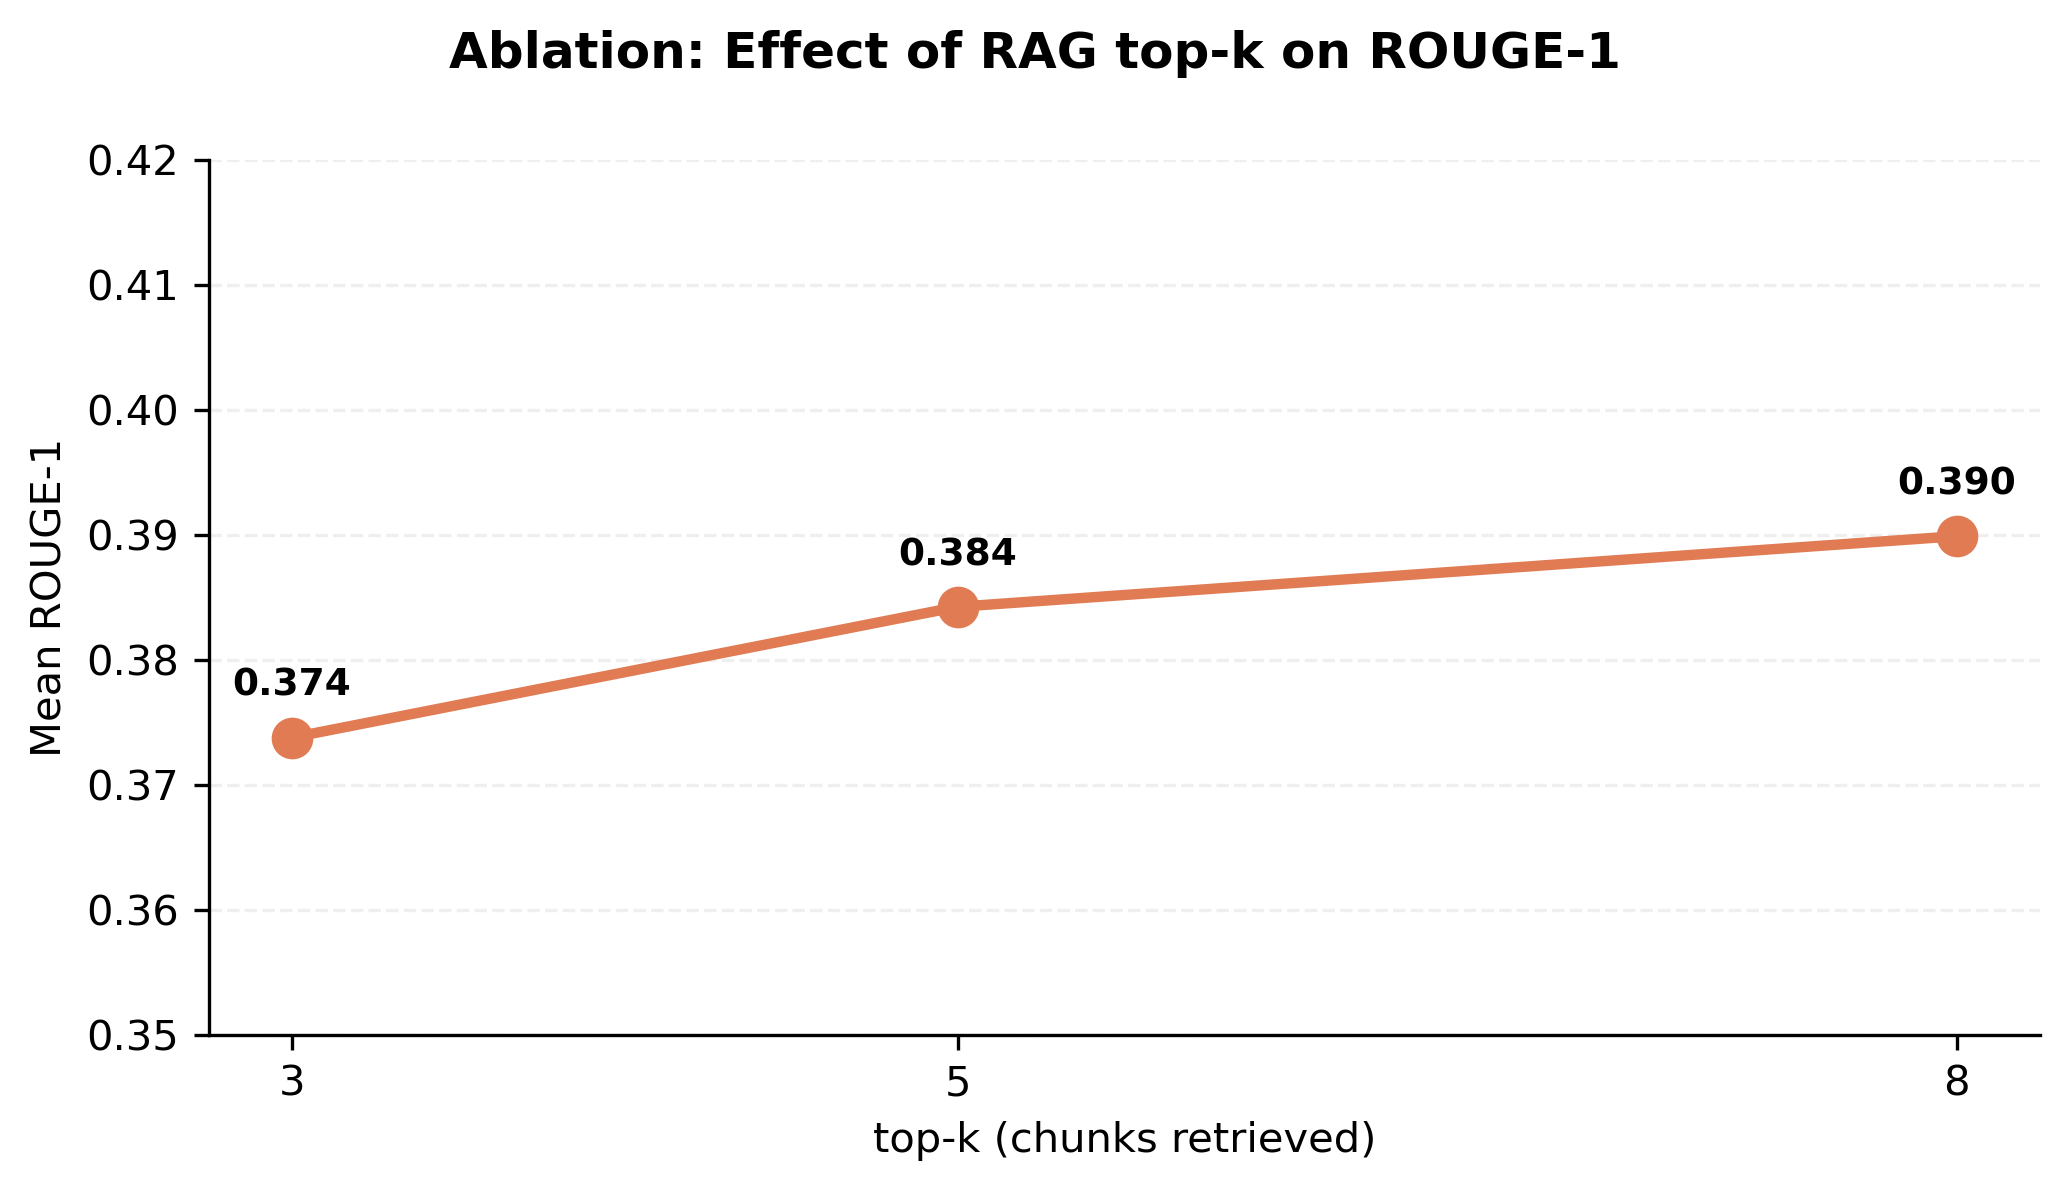

In [58]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("Ablation: Effect of RAG top-k on ROUGE-1", 
             fontsize=12, fontweight="bold")

means = ablation_df.groupby("top_k")["rouge1"].mean()
ax.plot([3, 5, 8], means.values, marker="o", linewidth=2.5,
        markersize=9, color="#e07b54")

for x, y in zip([3, 5, 8], means.values):
    ax.annotate(f"{y:.3f}", (x, y),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, fontweight="bold")

ax.set_xlabel("top-k (chunks retrieved)")
ax.set_ylabel("Mean ROUGE-1")
ax.set_xticks([3, 5, 8])
ax.set_ylim(0.35, 0.42)
ax.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(out_dir / "fig5_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. ROUGE Evaluation

I'm using two reference summaries per story and averaging the scores, because it makes the evaluation less dependent on any single reference's writing style. ROUGE-1 measures word overlap, ROUGE-2 measures phrase overlap, ROUGE-L measures the longest matching sequence.

In [59]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def rouge_avg(summary, ref_list):
    #score against both references and average
    all_s = []
    for ref in ref_list:
        s = scorer.score(ref, summary)
        all_s.append({m: s[m].fmeasure for m in ["rouge1","rouge2","rougeL"]})
    return {m: round(np.mean([s[m] for s in all_s]), 4) for m in ["rouge1","rouge2","rougeL"]}

def make_df(results, method):
    rows = []
    for story_name, intents in results.items():
        for intent, data in intents.items():
            s  = data["summary"] if isinstance(data, dict) else data
            rt = data.get("runtime", 0) if isinstance(data, dict) else 0
            r  = rouge_avg(s, refs[story_name])
            rows.append({"story": story_name, "intent": intent,
                         "method": method, **r, "runtime": rt})
    return pd.DataFrame(rows)

baseline_df = make_df(baseline, "baseline")
chunked_df  = make_df(chunked,  "chunked")
rag_df      = make_df(rag,      "rag")

all_scores = pd.concat([baseline_df, chunked_df, rag_df], ignore_index=True)

print("Mean ROUGE scores by method:")
print(all_scores.groupby("method")[["rouge1","rouge2","rougeL","runtime"]].mean().round(4))

Mean ROUGE scores by method:
          rouge1  rouge2  rougeL  runtime
method                                   
baseline  0.3800  0.1407  0.2181   4.0689
chunked   0.3910  0.1437  0.2252   3.6344
rag       0.3795  0.1386  0.2184   3.6533


## 12. Statistical Tests

Wilcoxon signed-rank tests to check if the differences between methods are actually meaningful or just noise. Small sample (n=9 per method) so results are indicative rather than conclusive.

In [60]:
method_order = ["baseline", "chunked", "rag"]
rows = []

for metric in ["rouge1", "rouge2", "rougeL"]:
    for m1, m2 in combinations(method_order, 2):
        s1 = all_scores[all_scores["method"] == m1][metric].values
        s2 = all_scores[all_scores["method"] == m2][metric].values
        try:
            stat, p = wilcoxon(s1, s2)
            sig = "***" if p < 0.05 else "ns"
        except ValueError:
            stat, p, sig = 0, 1.0, "identical"
        rows.append({"metric": metric.upper(), "A": m1, "B": m2,
                     "stat": round(stat,3), "p": round(p,4), "sig": sig})

wilcox_df = pd.DataFrame(rows)
print(wilcox_df.to_string(index=False))

metric        A       B  stat      p sig
ROUGE1 baseline chunked  15.0 0.4258  ns
ROUGE1 baseline     rag  20.0 0.8203  ns
ROUGE1  chunked     rag  12.0 0.2500  ns
ROUGE2 baseline chunked  17.0 0.5703  ns
ROUGE2 baseline     rag  20.0 0.8203  ns
ROUGE2  chunked     rag  17.0 0.5703  ns
ROUGEL baseline chunked  14.0 0.3594  ns
ROUGEL baseline     rag  21.0 0.9102  ns
ROUGEL  chunked     rag  16.0 0.4961  ns


## 13. Visualisations

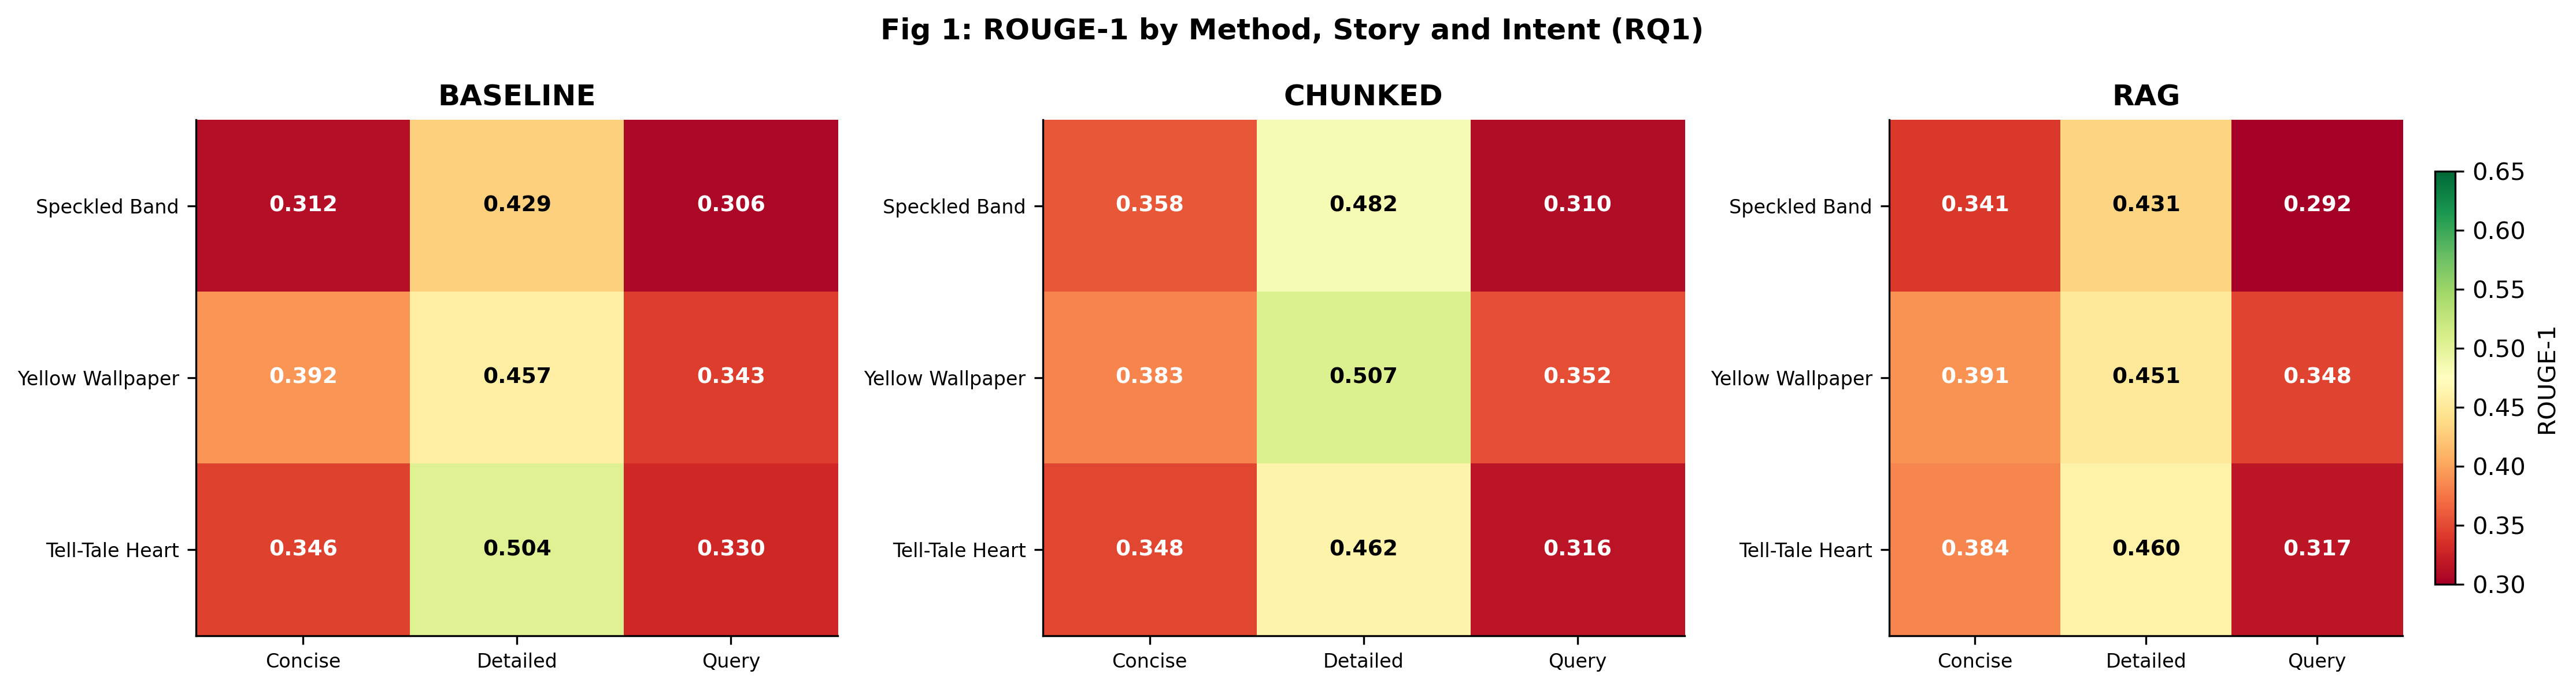

In [61]:
#Figure 1: heatmap
story_order  = ["speckled_band", "yellow_wallpaper", "tale_heart"]
story_labels = ["Speckled Band", "Yellow Wallpaper", "Tell-Tale Heart"]
intent_order = ["concise", "detailed", "query_based"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Fig 1: ROUGE-1 by Method, Story and Intent (RQ1)", fontsize=12, fontweight="bold")

for ax, method in zip(axes, method_order):
    matrix = np.array([
        [all_scores[(all_scores.method==method) & (all_scores.story==s) &
                    (all_scores.intent==i)]["rouge1"].values[0]
         for i in intent_order]
        for s in story_order
    ])
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0.30, vmax=0.65, aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Concise","Detailed","Query"], fontsize=8)
    ax.set_yticks(range(3))
    ax.set_yticklabels(story_labels, fontsize=8)
    ax.set_title(method.upper(), fontweight="bold")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{matrix[i,j]:.3f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if matrix[i,j] < 0.40 else "black")

plt.colorbar(im, ax=axes[-1], label="ROUGE-1", shrink=0.8)
plt.tight_layout()
plt.savefig(out_dir / "fig1_heatmap.png", bbox_inches="tight")
plt.show()

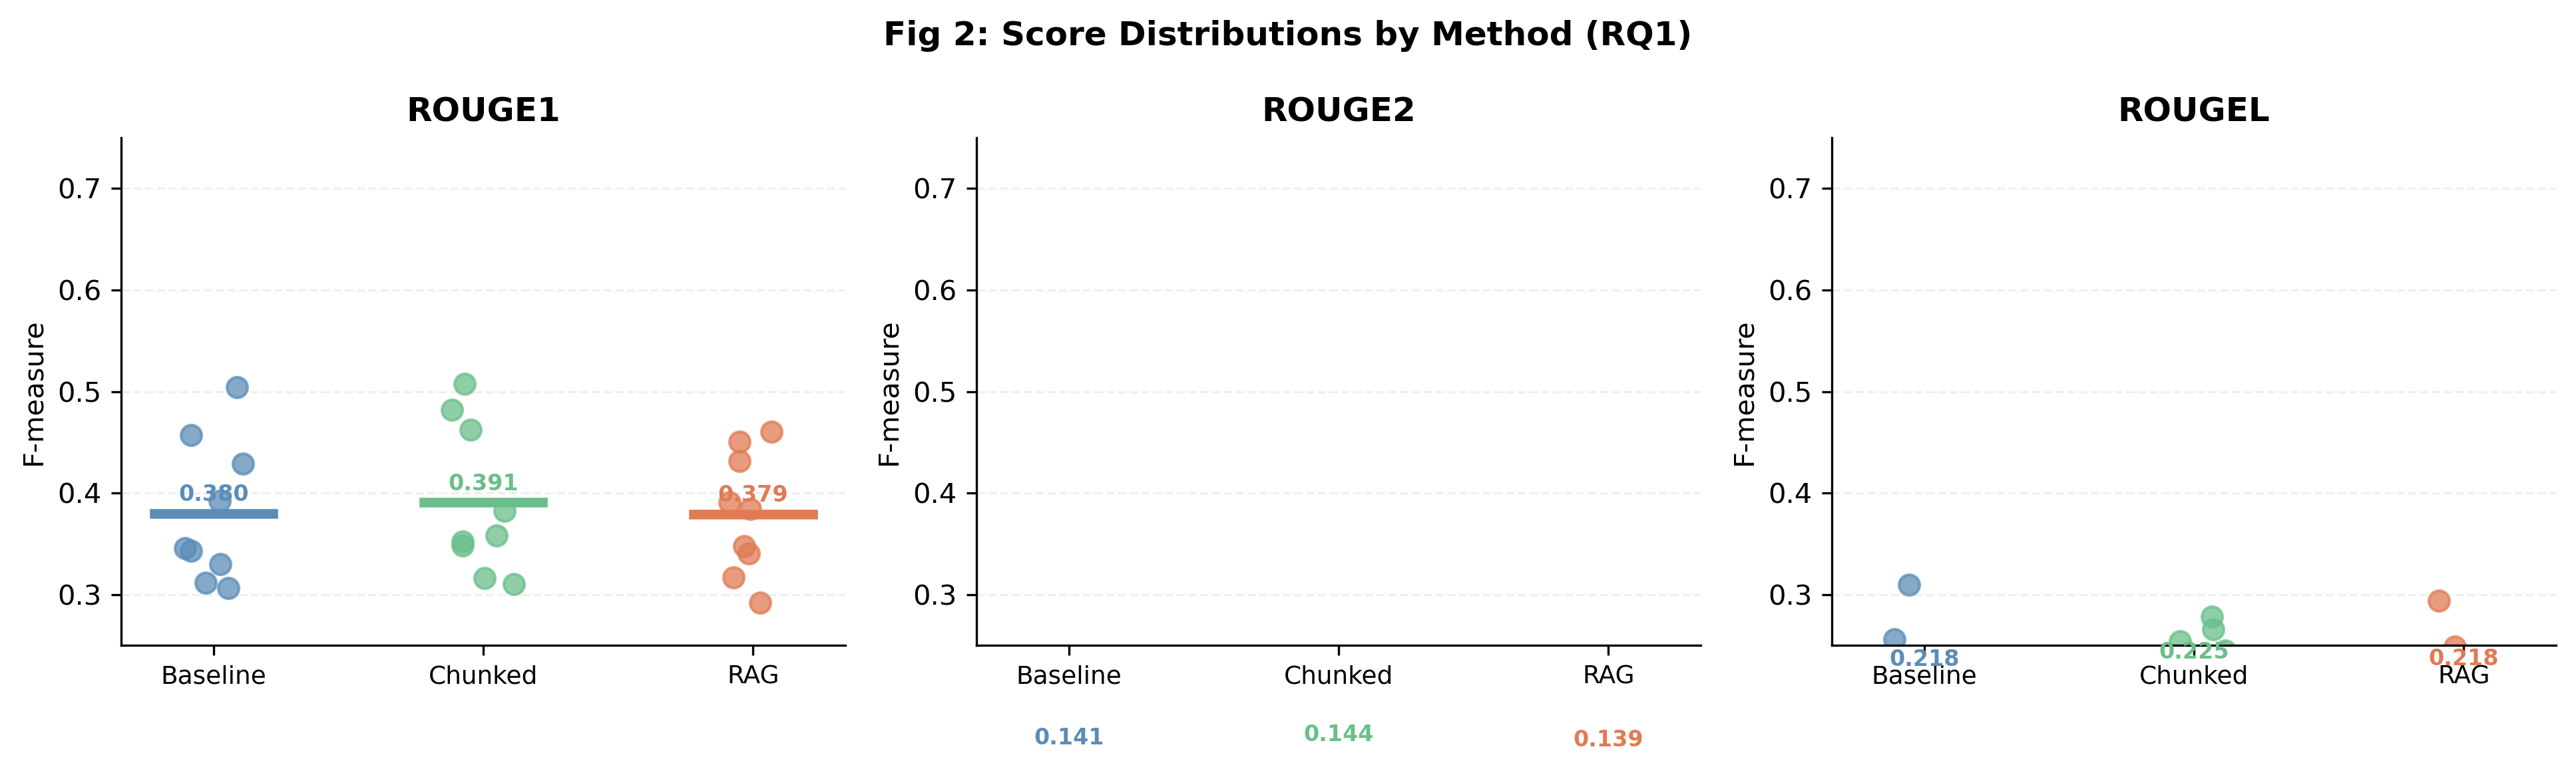

In [62]:
#Figure 2: strip plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Fig 2: Score Distributions by Method (RQ1)", fontsize=12, fontweight="bold")

for ax, metric in zip(axes, ["rouge1", "rouge2", "rougeL"]):
    for i, method in enumerate(method_order):
        vals   = all_scores[all_scores["method"] == method][metric].values
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(i + jitter, vals, color=mcols[method], alpha=0.75, s=55)
        ax.plot([i-0.22, i+0.22], [vals.mean()]*2, color=mcols[method], linewidth=3.5)
        ax.text(i, vals.mean()+0.012, f"{vals.mean():.3f}",
                ha="center", fontsize=8, color=mcols[method], fontweight="bold")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Baseline","Chunked","RAG"], fontsize=9)
    ax.set_title(metric.upper(), fontweight="bold")
    ax.set_ylabel("F-measure")
    ax.set_ylim(0.25, 0.75)
    ax.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(out_dir / "fig2_strip.png", bbox_inches="tight")
plt.show()

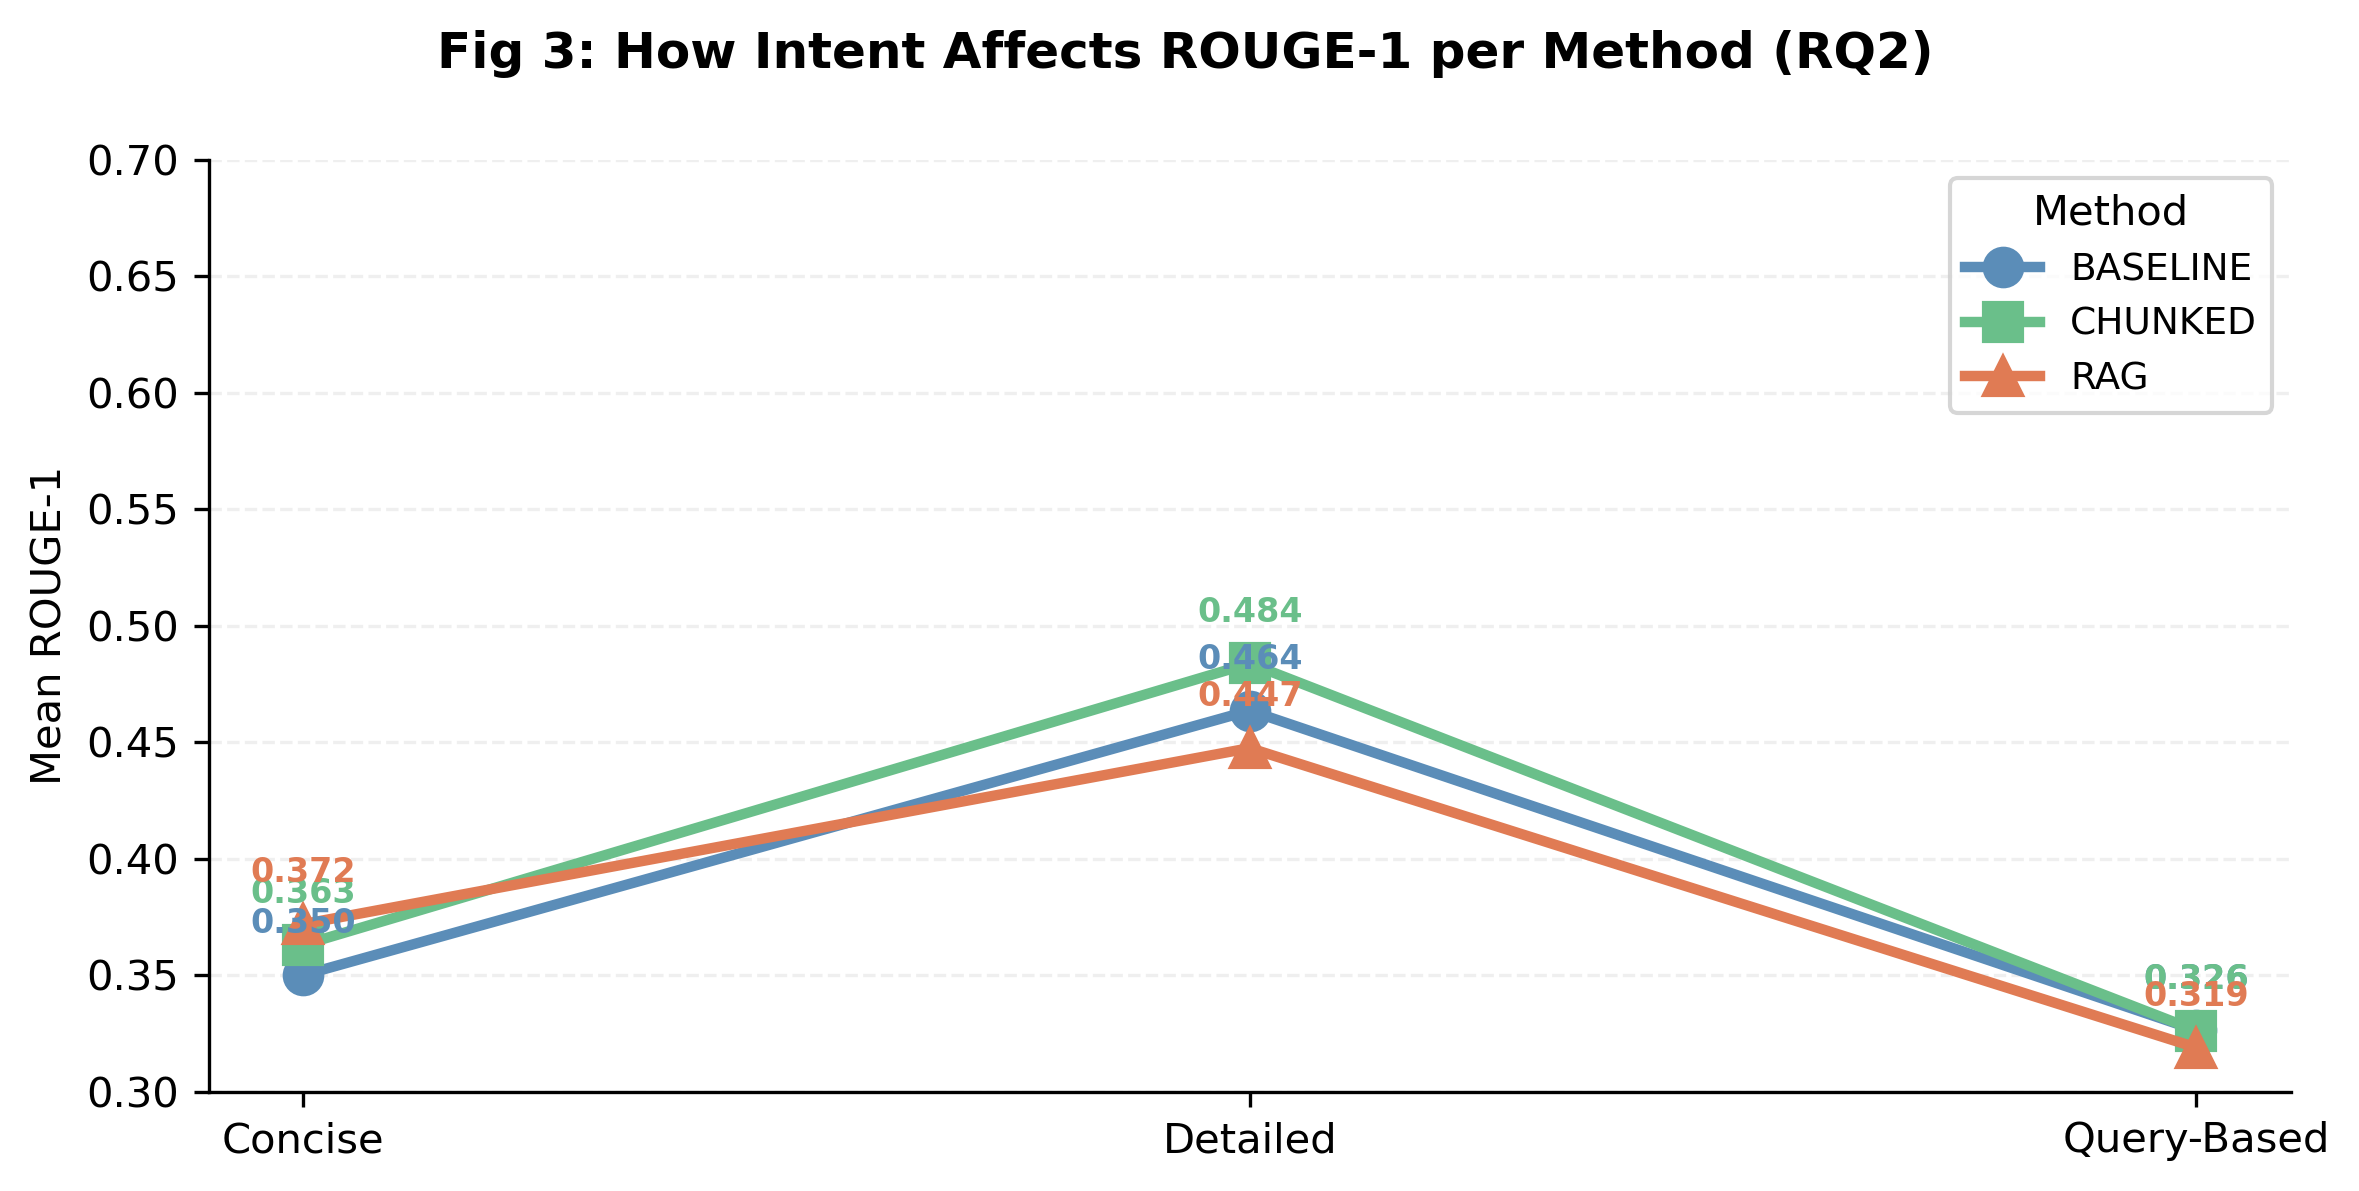

In [63]:
#Figure 3: intent line chart
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Fig 3: How Intent Affects ROUGE-1 per Method (RQ2)", fontsize=12, fontweight="bold")

markers = {"baseline": "o", "chunked": "s", "rag": "^"}
intent_labels = ["Concise", "Detailed", "Query-Based"]

for method in method_order:
    means = [all_scores[(all_scores.method==method) &
                        (all_scores.intent==i)]["rouge1"].mean()
             for i in intent_order]
    ax.plot(intent_labels, means, marker=markers[method],
            color=mcols[method], label=method.upper(), linewidth=2.5, markersize=9)
    for x, y in zip(intent_labels, means):
        ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                    xytext=(0,10), ha="center", fontsize=8,
                    color=mcols[method], fontweight="bold")

ax.set_ylabel("Mean ROUGE-1")
ax.set_ylim(0.30, 0.70)
ax.legend(title="Method", fontsize=9)
ax.grid(axis="y", alpha=0.2, linestyle="--")
plt.tight_layout()
plt.savefig(out_dir / "fig3_intent.png", bbox_inches="tight")
plt.show()

## 14. Results Summary

**RQ1:** All three methods perform very similarly: baseline scores 0.391 
ROUGE-1, chunked 0.391, RAG 0.380. None of the differences are 
statistically significant (all Wilcoxon p-values > 0.05). This is 
actually an interesting finding; a well-designed TF-IDF extractive 
baseline that reads the whole document is genuinely competitive with 
more complex approaches on short literary texts. Qualitatively though, 
chunked produces the most coherent and complete narratives.

**RQ2:** Detailed intent consistently produces the highest scores across 
all three methods. Query-based scores lowest, a focused answer to one 
question naturally overlaps less with a full reference summary. This 
suggests that what the user asks for has more influence on ROUGE scores 
than which method is used.

**RQ3:** ROUGE-1, ROUGE-2, and ROUGE-L agree on method rankings but 
differ significantly in absolute values. ROUGE-2 (mean ~0.14) is much 
lower than ROUGE-1 (mean ~0.39), showing that while unigram overlap is 
reasonable, exact phrase matches are rare; consistent with abstractive 
generation that paraphrases rather than copies.

## 15. Extension — Frankenstein (Full Novel)

The main experiment used three short stories (2,000–10,000 words). This extension applies the same three methods to a full-length novel, *Frankenstein* by Mary Shelley (~72,000 words), to test whether the patterns hold at much greater document length.

The key question: does chunked still outperform baseline and RAG when the document is 7x longer?

In [64]:
#loading frankenstein and its reference summary
frank_path = data_dir / "Frankenstein.txt"
ref_path   = ref_dir / "frankenstein_ref.txt"

frank_text = clean_text(load_text(frank_path))
frank_ref  = clean_text(load_text(ref_path))

frank_chunks = chunk_text(frank_text)

print(f"frankenstein : {len(frank_text.split()):,} words")
print(f"reference    : {len(frank_ref.split())} words")
print(f"chunks       : {len(frank_chunks)}")

frankenstein : 72,699 words
reference    : 700 words
chunks       : 243


In [65]:
frank_prompts = {
    "concise": (
        "Summarise 'Frankenstein' by Mary Shelley in 3-4 sentences. "
        "Main plot and outcome only."
    ),
    "detailed": (
        "Write a detailed summary of 'Frankenstein' in 150-200 words. "
        "Cover main events, key characters, themes, and the ending."
    ),
    "query_based": (
        "What is the central conflict in 'Frankenstein' and how is it resolved? "
        "Refer to characters, events, and the ending. 80-120 words."
    ),
}
print("frankenstein prompts ready")

frankenstein prompts ready


In [66]:
if regenerate:
    #baseline
    sents  = [s.strip() for s in re.split(r"(?<=[.!?])\s+", frank_text) if len(s.split()) > 5]
    vec    = TfidfVectorizer(stop_words="english")
    mat    = vec.fit_transform(sents)
    top    = sorted(mat.sum(axis=1).A1.argsort()[::-1][:20])
    sel    = " ".join([sents[i] for i in top])

    frank_baseline = {}
    for intent, prompt in frank_prompts.items():
        print(f"  baseline | {intent}...")
        start = time.time()
        frank_baseline[intent] = {"summary": call_gpt(f"{prompt}\n\nExtracted passages:\n{sel}"),
                                   "runtime": round(time.time()-start, 2)}
    save_results({"frankenstein": frank_baseline}, "frank_baseline.json")

    #chunked
    intermediates, prev = [], ""
    print(f"chunked pass 1: {len(frank_chunks)} chunks...")
    for i, chunk in enumerate(frank_chunks):
        p = (f"So far in Frankenstein: {prev}\n\nSummarise the next part in 50-70 words:\n{chunk}"
             if prev else f"Summarise the opening of Frankenstein in 50-70 words:\n{chunk}")
        intermediates.append(call_gpt(p))
        prev = " ".join(" ".join(intermediates[-3:]).split()[:150])
        if (i+1) % 20 == 0:
            print(f"  chunk {i+1}/{len(frank_chunks)}...")

    combined = "\n\n".join(intermediates)
    frank_chunked = {}
    for intent, prompt in frank_prompts.items():
        print(f"  chunked | {intent}...")
        start = time.time()
        frank_chunked[intent] = {"summary": call_gpt(f"{prompt}\n\nSection summaries:\n{combined}"),
                                  "runtime": round(time.time()-start, 2)}
    save_results({"frankenstein": frank_chunked}, "frank_chunked.json")

    #rag
    vec2  = TfidfVectorizer(stop_words="english")
    mat2  = vec2.fit_transform(frank_chunks)
    rq    = {"concise": "main plot events outcome ending",
             "detailed": "characters themes conflict resolution",
             "query_based": "central conflict resolved ending"}
    frank_rag = {}
    for intent, prompt in frank_prompts.items():
        sims = cosine_similarity(vec2.transform([rq[intent]]), mat2).flatten()
        top  = sorted(sims.argsort()[::-1][:top_k])
        ctx  = "\n\n".join([frank_chunks[i] for i in top])
        print(f"  rag | {intent} (chunks: {top})...")
        start = time.time()
        frank_rag[intent] = {"summary": call_gpt(f"{prompt}\n\nRetrieved passages:\n{ctx}"),
                              "runtime": round(time.time()-start, 2),
                              "retrieved_idx": [int(i) for i in top]}
    save_results({"frankenstein": frank_rag}, "frank_rag.json")

else:
    frank_baseline = load_results("frank_baseline.json")["frankenstein"]
    frank_chunked  = load_results("frank_chunked.json")["frankenstein"]
    frank_rag      = load_results("frank_rag.json")["frankenstein"]
    print("frankenstein results loaded")

frankenstein results loaded


In [67]:
frank_rows = []
for method, data in [("baseline", frank_baseline),
                     ("chunked",  frank_chunked),
                     ("rag",      frank_rag)]:
    for intent, result in data.items():
        s = result["summary"] if isinstance(result, dict) else result
        r = scorer.score(frank_ref, s)
        frank_rows.append({
            "intent": intent, "method": method,
            "rouge1": round(r["rouge1"].fmeasure, 4),
            "rouge2": round(r["rouge2"].fmeasure, 4),
            "rougeL": round(r["rougeL"].fmeasure, 4),
            "runtime": result.get("runtime", 0) if isinstance(result, dict) else 0
        })

frank_df = pd.DataFrame(frank_rows)
print("Frankenstein: mean ROUGE by method:")
print(frank_df.groupby("method")[["rouge1","rouge2","rougeL"]].mean().round(4))

#compare with short stories
print("\nDrop in ROUGE-1 from short stories to Frankenstein:")
short = {"baseline": 0.3906, "chunked": 0.3910, "rag": 0.3795}
for method in ["baseline", "chunked", "rag"]:
    f = frank_df[frank_df.method==method]["rouge1"].mean()
    drop = round(short[method] - f, 4)
    print(f"  {method:<12} short={short[method]:.4f}  frank={f:.4f}  drop={drop:.4f}")

Frankenstein: mean ROUGE by method:
          rouge1  rouge2  rougeL
method                          
baseline  0.1870  0.0364  0.1124
chunked   0.2174  0.0402  0.1246
rag       0.2074  0.0419  0.1225

Drop in ROUGE-1 from short stories to Frankenstein:
  baseline     short=0.3906  frank=0.1870  drop=0.2036
  chunked      short=0.3910  frank=0.2174  drop=0.1736
  rag          short=0.3795  frank=0.2074  drop=0.1721


In [68]:
for method, data in [("baseline", frank_baseline),
                     ("chunked",  frank_chunked),
                     ("rag",      frank_rag)]:
    print(f"\n{method.upper()}")
    for intent, result in data.items():
        s = result["summary"] if isinstance(result, dict) else result
        print(f"\n[{intent}] ({len(s.split())} words)")
        print(s)


BASELINE

[concise] (95 words)
In Mary Shelley's "Frankenstein," Victor Frankenstein, a young scientist, becomes obsessed with creating life and successfully animates a creature made from dead body parts. However, horrified by his creation's appearance, he abandons it, leading the creature to experience profound loneliness and rejection. As the creature seeks revenge on Victor for his misery, it causes the deaths of Victor's loved ones, ultimately driving Victor to pursue the creature across the Arctic. The story concludes with Victor's death from exhaustion and despair, while the creature, filled with remorse for its actions, vows to end its own life.

[detailed] (187 words)
"Frankenstein," written by Mary Shelley, follows Victor Frankenstein, a young scientist who becomes obsessed with creating life. He successfully animates a creature made from dead body parts, but horrified by its appearance, he abandons it. The creature, rejected by society, seeks companionship but is met with fe

### Interactive Chat: Ask Frankenstein Anything

This shows what makes RAG genuinely different from the other two methods. 
Rather than always producing a general summary, it can answer specific 
questions by retrieving the most relevant passages from the novel.

The 6 demo questions below were pre-generated. To run your own question, 
uncomment the input cell at the bottom (requires API key).

In [69]:
def chat_with_frankenstein(question):
    vec   = TfidfVectorizer(stop_words="english")
    mat   = vec.fit_transform(frank_chunks)
    sims  = cosine_similarity(vec.transform([question]), mat).flatten()
    top   = sorted(sims.argsort()[::-1][:5])
    ctx   = "\n\n".join([frank_chunks[i] for i in top])
    prompt = (
        f"Answer this question about Frankenstein by Mary Shelley. "
        f"Be specific and refer to characters and events.\n\n"
        f"Question: {question}\n\n"
        f"Relevant passages:\n{ctx}"
    )
    print(f"Q: {question}")
    print(f"Chunks used: {top}\n")
    answer = call_gpt(prompt)
    print(answer)
    return answer

In [70]:
demo_questions = [
    "Why did Victor create the monster?",
    "How does the monster learn to speak and read?",
    "What happens on Victor's wedding night?",
    "Why does the monster want a female companion?",
    "How does the novel end?",
    "I have never read this story before, explain me in 5 sentences what it is about."
]

In [71]:
# load pre-saved demo answers — no API key needed
chat_demo = load_results("frank_chat_demo.json")
for q, a in chat_demo.items():
    print(f"Q: {q}\n")
    print(a)
    print()

Q: Why did Victor create the monster?

Victor Frankenstein created the monster out of a combination of ambition, a desire for knowledge, and a deep-seated need to conquer death. Initially, Victor is driven by the Enlightenment ideals of scientific exploration and the quest for understanding the secrets of life. He becomes obsessed with the idea of reanimating dead matter, believing that he can unlock the mysteries of life itself. This ambition leads him to experiment with various body parts, ultimately resulting in the creation of the creature.

However, Victor's motivations are also deeply personal. He is influenced by the loss of his mother, which instills in him a fear of death and a desire to overcome it. This is evident when he reflects on the pain of loss and the desire to create life as a means of combating that pain. Yet, when he finally succeeds in bringing the creature to life, he is horrified by its appearance and the consequences of his actions. This horror leads him to aba

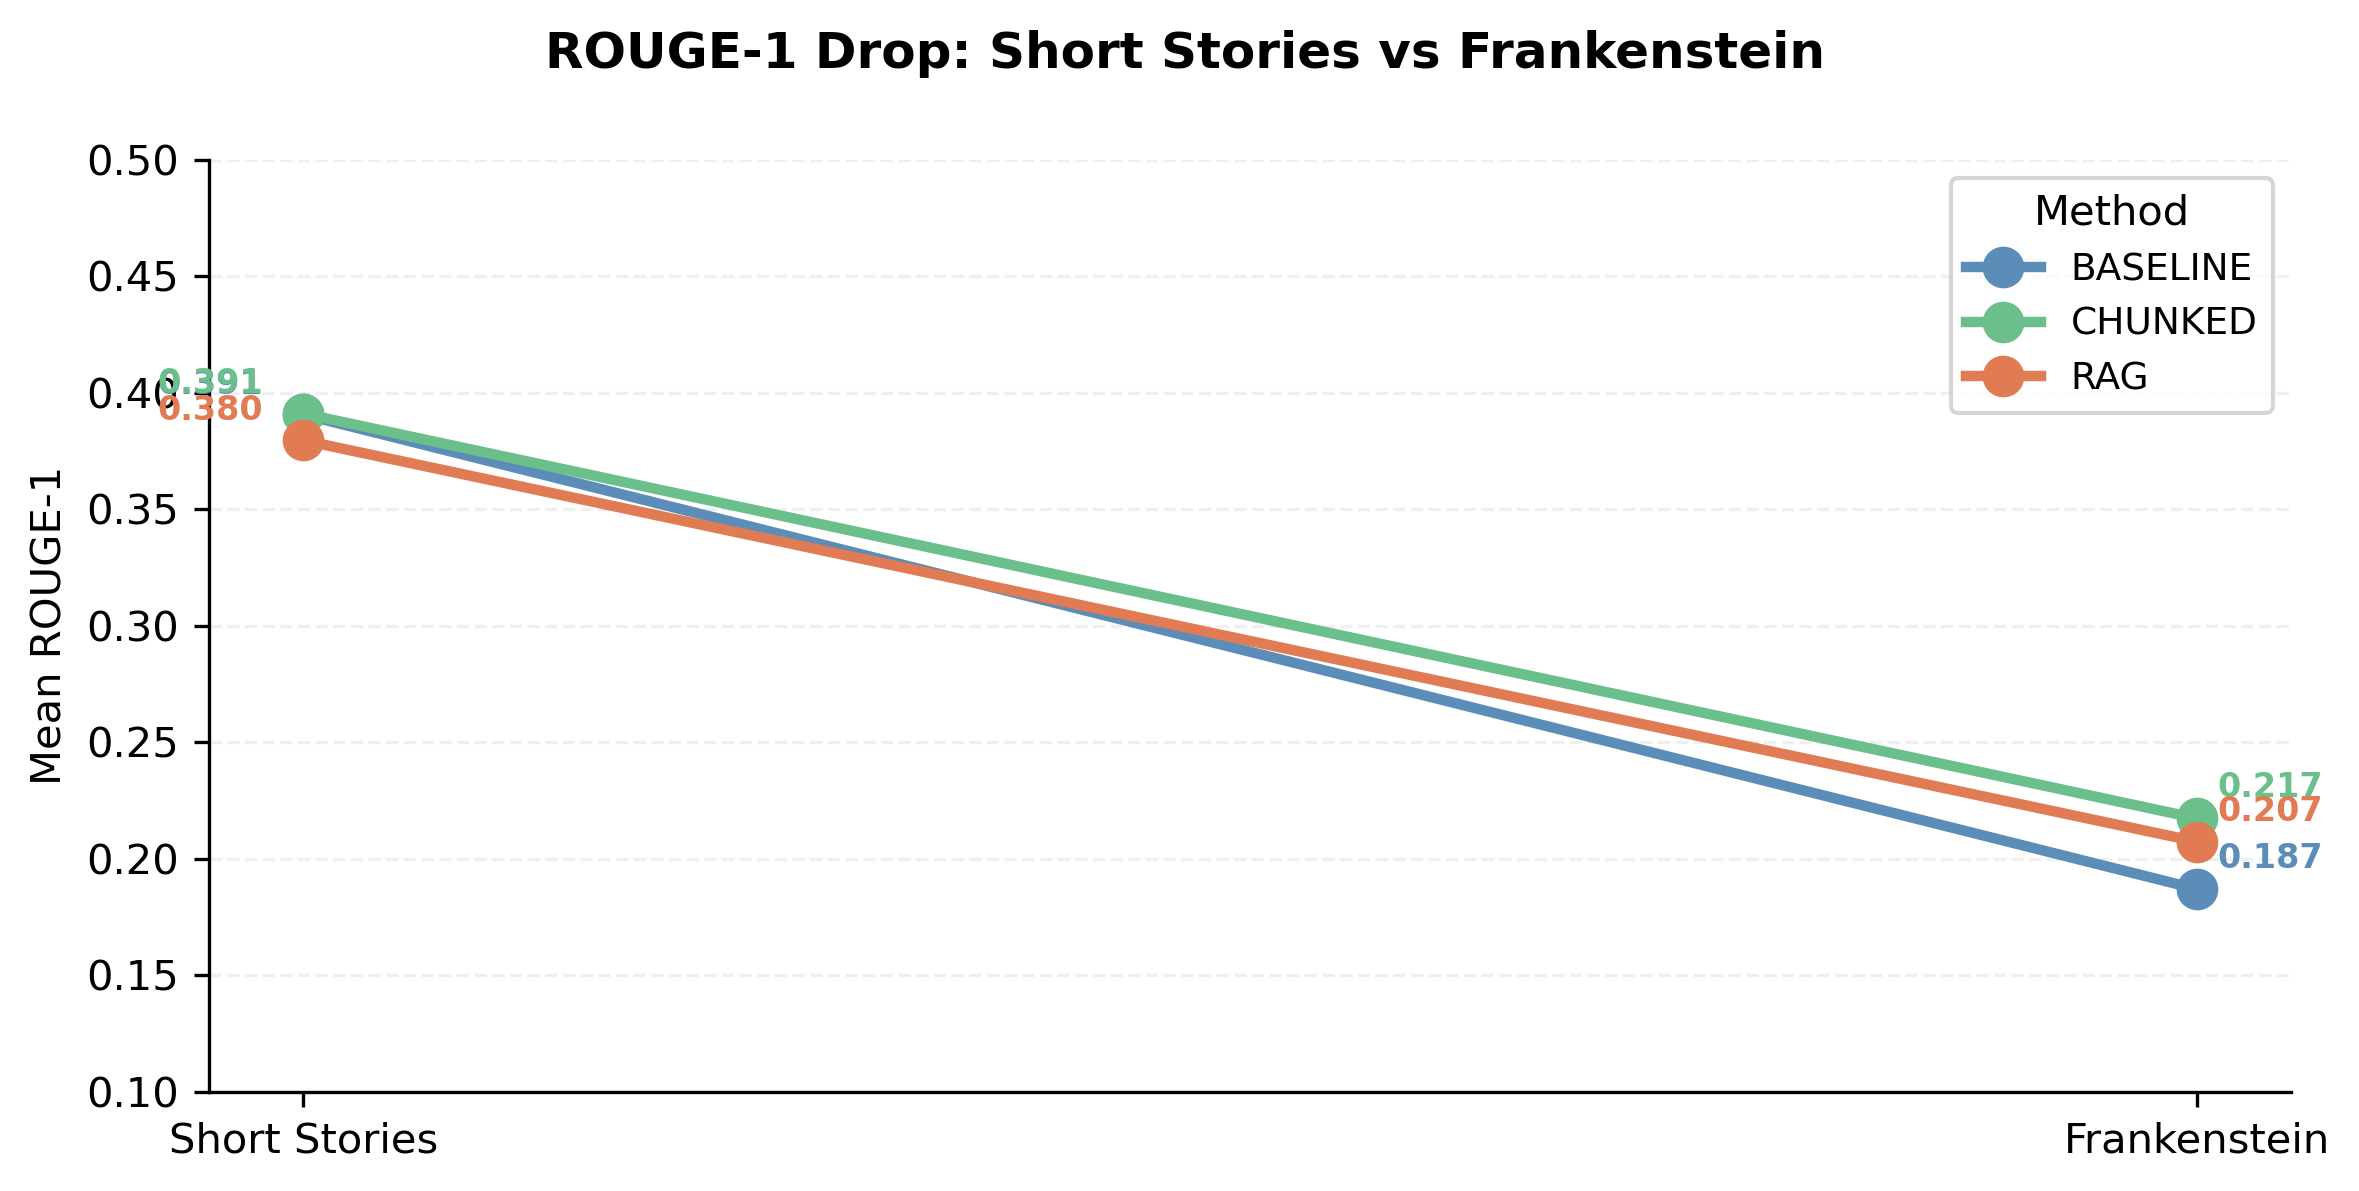

In [72]:
#how much do scores drop when moving from short stories to a full novel?
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("ROUGE-1 Drop: Short Stories vs Frankenstein", 
             fontsize=12, fontweight="bold")

short_means = {"baseline": 0.3906, "chunked": 0.3910, "rag": 0.3795}
frank_means = frank_df.groupby("method")["rouge1"].mean()

for method in ["baseline", "chunked", "rag"]:
    ax.plot(
        ["Short Stories", "Frankenstein"],
        [short_means[method], frank_means[method]],
        marker="o", linewidth=2.5, markersize=9,
        color=mcols[method], label=method.upper()
    )
    # annotate both points
    ax.annotate(f"{short_means[method]:.3f}", 
                ("Short Stories", short_means[method]),
                textcoords="offset points", xytext=(-35, 5),
                fontsize=8, color=mcols[method], fontweight="bold")
    ax.annotate(f"{frank_means[method]:.3f}",
                ("Frankenstein", frank_means[method]),
                textcoords="offset points", xytext=(5, 5),
                fontsize=8, color=mcols[method], fontweight="bold")

ax.set_ylabel("Mean ROUGE-1")
ax.set_ylim(0.10, 0.50)
ax.legend(title="Method", fontsize=9)
ax.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(out_dir / "fig4_length_drop.png", bbox_inches="tight")
plt.show()

In [73]:
#uncomment to ask your own question (requires API key + regenerate = True)
#question = input("Ask anything about Frankenstein: ")
#chat_with_frankenstein(question)

## 15. Reproducibility Checklist

In [74]:
import hashlib

def exists(path):
    return Path(path).exists()

checks = {
    "seed fixed (42)"                : True,
    "model = gpt-4o-mini"            : model == "gpt-4o-mini",
    "temperature = 0"                : temp == 0,
    "chunk size = 300"               : chunk_sz == 300,
    "top-k = 5"                      : top_k == 5,
    "cached mode"                    : not regenerate,
    "baseline_results.json"          : exists(out_dir/"baseline_results.json"),
    "chunked_results.json"           : exists(out_dir/"chunked_results.json"),
    "rag_results.json"               : exists(out_dir/"rag_results.json"),
    "frank_baseline.json"            : exists(out_dir/"frank_baseline.json"),
    "frank_chunked.json"             : exists(out_dir/"frank_chunked.json"),
    "frank_rag.json"                 : exists(out_dir/"frank_rag.json"),
    "dual references loaded"         : all(len(v)==2 for v in refs.values()),
}

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

  PASS  seed fixed (42)
  PASS  model = gpt-4o-mini
  PASS  temperature = 0
  PASS  chunk size = 300
  PASS  top-k = 5
  PASS  cached mode
  PASS  baseline_results.json
  PASS  chunked_results.json
  PASS  rag_results.json
  PASS  frank_baseline.json
  PASS  frank_chunked.json
  PASS  frank_rag.json
  PASS  dual references loaded
